### Importar bibliotecas

In [1]:
import pandas as pd
import numpy as np 
import math
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats
import plotly.express as px
# import mlrose_hiive as mlrose

import joblib
import sklearn
import mlrose_hiive as mlrose

In [2]:
import nbformat
print(nbformat.__version__)

5.10.4


### Importar base de dados

In [3]:
df = (pd.read_csv('acoes.csv').rename(columns={'Unnamed: 0': 'Date'}))
# df = df.rename(columns={'Unnamed: 0': 'Date'})
print(df.shape)
df.head()

(1037, 7)


,Date,VALE3.SA,PETR4.SA,BBDC4.SA,ABEV3.SA,EMBR3.SA,BOVA11.SA
0,2021-01-04,91.46,28.91,26.43,15.48,8.37,114.09
1,2021-01-05,93.00,30.04,26.25,15.81,8.57,114.69
2,2021-01-06,96.05,30.10,27.12,16.05,8.90,114.55
3,2021-01-07,102.32,31.00,27.84,16.05,8.88,118.37
4,2021-01-08,102.00,31.12,27.60,16.53,8.81,120.40


In [4]:
df.tail()

,Date,VALE3.SA,PETR4.SA,BBDC4.SA,ABEV3.SA,EMBR3.SA,BOVA11.SA
1032,2025-02-24,57.63,38.12,11.63,11.03,59.89,122.49
1033,2025-02-25,57.07,37.95,11.77,11.09,60.62,122.83
1034,2025-02-26,56.72,37.95,11.54,11.70,61.45,121.82
1035,2025-02-27,56.30,36.61,11.47,12.32,68.90,121.75
1036,2025-02-28,55.15,35.93,11.24,12.22,69.72,120.07


### Alocação aleatória de ativos

In [5]:
def alocacao_ativos(df, dinheiro, seed = 0, melhores_pesos = []):
    df = df.copy()

    if seed != 0:
        np.random.seed(seed)

    if len(melhores_pesos) > 0:
        pesos = melhores_pesos
    else:
        pesos = np.random.random(len(df.columns) - 1)
        pesos = pesos / pesos.sum()
    # print(pesos, pesos.sum())

    colunas = df.columns[1:]
    # print(colunas)
    for i in colunas:
        df[i] = (df[i] / df[i][0])
    for i, acao in enumerate(df.columns[1:]):
        # print(i, acao)
        df[acao] = df[acao] * pesos[i] * dinheiro

    df['Soma_Total'] = df.select_dtypes(include='number').sum(axis=1)

    datas = df['Date']
    # print(datas):
    df.drop(labels= ['Date'], axis = 1, inplace = True)
    df['Taxa_Retorno'] = 0.0

    # for i in range(1, len(df)):
    #     df['Taxa_Retorno'][i] = ((df['Soma_Total'][i] / df['Soma_Total'][i-1]) - 1) * 100

    for i in range(1, len(df)):
        df.loc[i, 'Taxa_Retorno'] = ((df.loc[i, 'Soma_Total'] / df.loc[i - 1, 'Soma_Total']) - 1) * 100

    acoes_pesos = pd.DataFrame(data= {'Acoes': colunas, 'Pesos': pesos * 100}) 
    
        
    return df, datas, acoes_pesos, df.loc[len(df) - 1]['Soma_Total']

In [6]:
df, datas, acoes_pesos, soma_total = alocacao_ativos((pd.read_csv('acoes.csv').rename(columns={'Unnamed: 0': 'Date'})), 5000, 10)

In [7]:
# round((11787.755497 - 5000.000000) / 5000.000000 * 100, 2)
df

,VALE3.SA,PETR4.SA,BBDC4.SA,ABEV3.SA,EMBR3.SA,BOVA11.SA,Soma_Total,Taxa_Retorno
0,1330.859777,35.806036,1093.315674,1292.008683,860.138954,387.870876,5000.000000,0.000000
1,1353.268744,37.205580,1085.869710,1319.551504,880.691856,389.910691,5066.498085,1.329962
2,1397.650138,37.279892,1121.858535,1339.582646,914.604145,389.434734,5200.410090,2.643088
3,1488.886643,38.394573,1151.642390,1339.582646,912.548855,402.421558,5333.476665,2.558771
4,1484.230235,38.543197,1141.714438,1379.644931,905.355339,409.322933,5358.811073,0.475007
...,...,...,...,...,...,...,...,...
1032,838.590083,47.212940,481.091990,920.597918,6154.566542,416.428290,8858.487763,0.731634
1033,830.441368,47.002389,486.883295,925.605704,6229.584635,417.584185,8937.101576,0.887441
1034,825.348421,47.002389,477.369008,976.518191,6314.879179,414.150496,9055.267683,1.322197
1035,819.236885,45.342753,474.473355,1028.265308,7080.474783,413.912518,9861.705602,8.905733


In [8]:
datas

0       2021-01-04
1       2021-01-05
2       2021-01-06
3       2021-01-07
4       2021-01-08
           ...    
1032    2025-02-24
1033    2025-02-25
1034    2025-02-26
1035    2025-02-27
1036    2025-02-28
Name: Date, Length: 1037, dtype: object

In [9]:
acoes_pesos

,Acoes,Pesos
0,VALE3.SA,26.617196
1,PETR4.SA,0.716121
2,BBDC4.SA,21.866313
3,ABEV3.SA,25.840174
4,EMBR3.SA,17.202779
5,BOVA11.SA,7.757418


In [10]:
soma_total

9904.824249559313

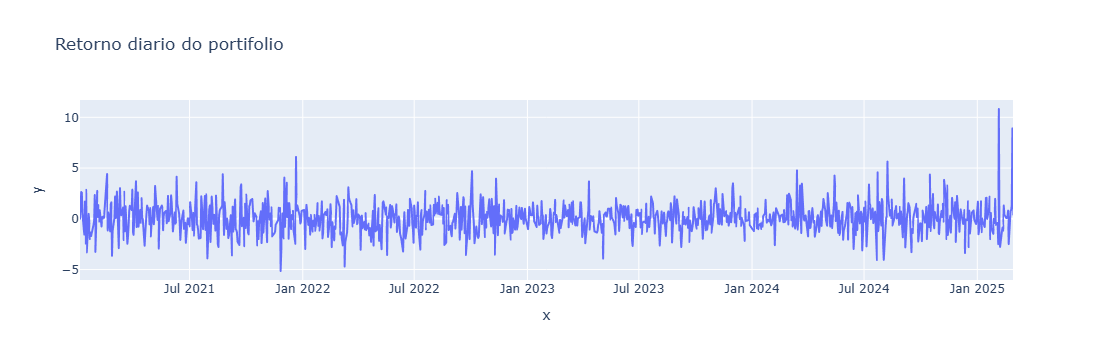

In [11]:
figura = px.line(x=datas, y=df['Taxa_Retorno'], title='Retorno diario do portifolio')
figura.show()

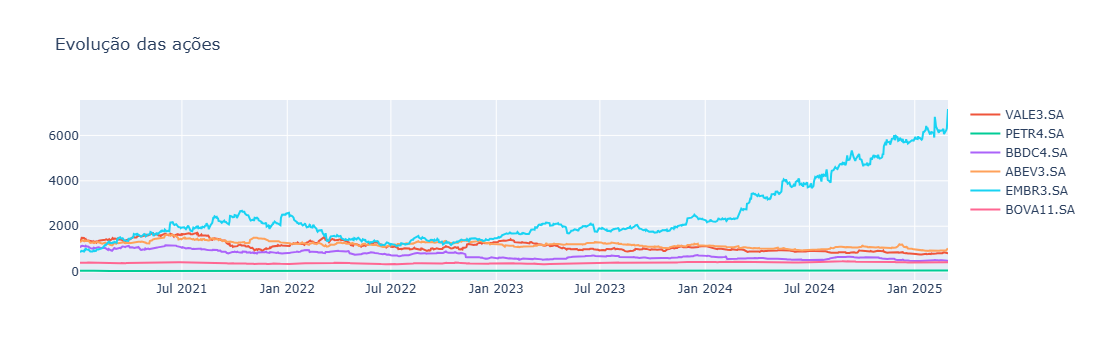

In [12]:
figura = px.line(title='Evolução das ações')
for i  in df.drop(columns=['Soma_Total', 'Taxa_Retorno']).columns:
    figura.add_scatter(x = datas,  y = df[i], name=i)
figura.show()

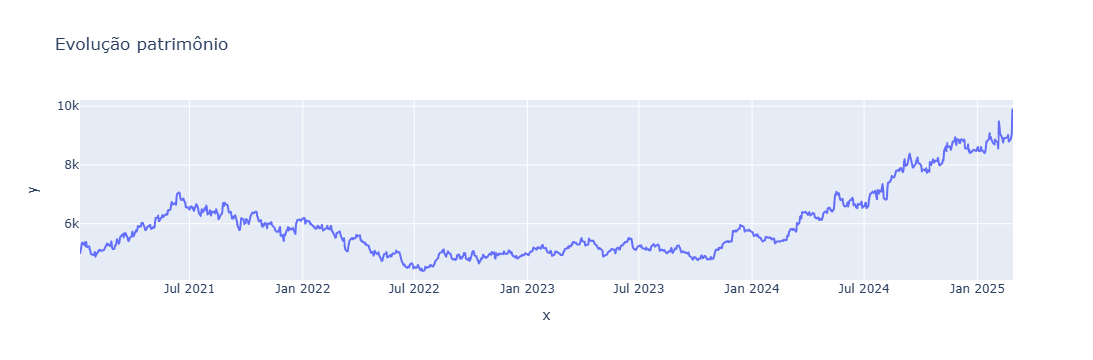

In [13]:
figura = px.line(x=datas, y=df['Soma_Total'], title='Evolução patrimônio')
figura.show()

### Sharpe Ratio

#### Retorno acumulado em todo período

In [14]:
df.loc[len(df) - 1]['Soma_Total'] / df.loc[0]['Soma_Total'] - 1

0.9809648499118626

#### Desvio Padrão

In [15]:
df['Taxa_Retorno'].std()

1.5062285495292627

#### Sharpe Ratio

In [16]:
(df['Taxa_Retorno'].mean() / df['Taxa_Retorno'].std()) * np.sqrt(246)

0.8038884085435226

In [17]:
dinheiro_total = 5000

df['Soma_Total'].iloc[-1] - dinheiro_total

4904.824249559313

In [18]:
taxa_selic_2021 = 3.91
taxa_selic_2022 = 12.34
taxa_selic_2023 = 13.18
taxa_selic_2024 = 10.83
taxa_selic_2025 = 14.17

valor_total_2021 = dinheiro_total + (dinheiro_total * taxa_selic_2021 / 100)
valor_total_2022 = valor_total_2021 + (valor_total_2021 * taxa_selic_2022 / 100)
valor_total_2023 = valor_total_2022 + (valor_total_2022 * taxa_selic_2023 / 100)
valor_total_2024 = valor_total_2023 + (valor_total_2023 * taxa_selic_2024 / 100)
valor_total_2025 = valor_total_2024 + (valor_total_2024 * taxa_selic_2025 / 100)
valor_total_2025

8358.73953708007

In [19]:
rendimentos = valor_total_2025 - dinheiro_total
rendimentos

3358.7395370800696

In [20]:
ir = rendimentos * 0.15
ir

503.8109305620104

In [21]:
rendimnento_liq = rendimentos - ir
rendimnento_liq

2854.928606518059

In [22]:
taxa_selic_historico = np.array([3.91, 12.34, 13.18, 10.83, 14.17])
taxa_selic_historico.mean()

10.886

#### Analise do Shape ratio levando en consideração ativos livres de risco

In [23]:
(df['Taxa_Retorno'].mean() - (taxa_selic_historico.mean()/ 100) / df['Taxa_Retorno'].std()) * np.sqrt(246) 

0.07727837722265653

#### Alocação de Morkowitz

In [24]:
import sys
1 - sys.maxsize

-9223372036854775806

In [26]:
df.head()

,VALE3.SA,PETR4.SA,BBDC4.SA,ABEV3.SA,EMBR3.SA,BOVA11.SA,Soma_Total,Taxa_Retorno
0,1330.859777,35.806036,1093.315674,1292.008683,860.138954,387.870876,5000.000000,0.000000
1,1353.268744,37.205580,1085.869710,1319.551504,880.691856,389.910691,5066.498085,1.329962
2,1397.650138,37.279892,1121.858535,1339.582646,914.604145,389.434734,5200.410090,2.643088
3,1488.886643,38.394573,1151.642390,1339.582646,912.548855,402.421558,5333.476665,2.558771
4,1484.230235,38.543197,1141.714438,1379.644931,905.355339,409.322933,5358.811073,0.475007


In [27]:
def alocacao_portfolio(dataset, dinheiro_total, sem_risco, repeticoes):
  dataset = dataset.copy()
  dataset_original = dataset.copy()

  lista_retorno_esperado = []
  lista_volatilidade_esperada = []
  lista_sharpe_ratio = []

  melhor_sharpe_ratio = 1 - sys.maxsize
  melhores_pesos = np.empty
  melhor_volatilidade = 0
  melhor_retorno = 0

  for _ in range(repeticoes):
    pesos = np.random.random(len(dataset.columns) - 1)
    pesos = pesos / pesos.sum()

    for i in dataset.columns[1:]:
      dataset[i] = dataset[i] / dataset[i][0]

    for i, acao in enumerate(dataset.columns[1:]):
      dataset[acao] = dataset[acao] * pesos[i] * dinheiro_total

    dataset.drop(labels = ['Date'], axis = 1, inplace=True)

    retorno_carteira = np.log(dataset / dataset.shift(1))
    matriz_covariancia = retorno_carteira.cov()

    dataset['Soma_Total'] = dataset.sum(axis = 1)
    dataset['Taxa_Retorno'] = 0.0

    for i in range(1, len(df)):
        dataset.loc[i, 'Taxa_Retorno'] = ((dataset.loc[i, 'Soma_Total'] / dataset.loc[i - 1, 'Soma_Total']) - 1) * 100

    #sharpe_ratio = (dataset['taxa retorno'].mean() - sem_risco) / dataset['taxa retorno'].std() * np.sqrt(246)
    retorno_esperado = np.sum(dataset['Taxa_Retorno'].mean() * pesos) * 246
    volatilidade_esperada = np.sqrt(np.dot(pesos, np.dot(matriz_covariancia * 246, pesos)))
    sharpe_ratio = (retorno_esperado - sem_risco) / volatilidade_esperada

    # print(dataset['Taxa_Retorno'].head())
    if sharpe_ratio > melhor_sharpe_ratio:
      melhor_sharpe_ratio = sharpe_ratio
      melhores_pesos = pesos
      melhor_volatilidade = volatilidade_esperada
      melhor_retorno = retorno_esperado

    lista_retorno_esperado.append(retorno_esperado)
    lista_volatilidade_esperada.append(volatilidade_esperada)
    lista_sharpe_ratio.append(sharpe_ratio)

    dataset = dataset_original.copy()

  return melhor_sharpe_ratio, melhores_pesos, lista_retorno_esperado, lista_volatilidade_esperada, lista_sharpe_ratio, melhor_volatilidade, melhor_retorno

In [28]:
sharpe_ratio, melhores_pesos, ls_retorno, ls_volatilidade, ls_shape_ratio, melhor_volatilidade, melhor_retono = alocacao_portfolio((pd.read_csv('acoes.csv').rename(columns={'Unnamed: 0': 'Date'})), 5000, (taxa_selic_historico.mean() / 100), 1000)

In [29]:
sharpe_ratio

157.73580727810204

In [30]:
melhores_pesos

array([0.0096989 , 0.11952165, 0.03287257, 0.06056845, 0.44410075,
       0.33323769])

In [31]:
melhores_pesos.sum()

1.0

In [32]:
_, _, acoes_pesos, soma_valor = alocacao_ativos((pd.read_csv('acoes.csv').rename(columns={'Unnamed: 0': 'Date'})), 
                                                5000, 0, melhores_pesos = melhores_pesos)

In [33]:
acoes_pesos

,Acoes,Pesos
0,VALE3.SA,0.969890
1,PETR4.SA,11.952165
2,BBDC4.SA,3.287257
3,ABEV3.SA,6.056845
4,EMBR3.SA,44.410075
5,BOVA11.SA,33.323769


In [34]:
soma_valor

21330.6879822068

In [35]:
# print(ls_retorno)

In [36]:
# print(ls_volatilidade)

In [37]:
# print(ls_shape_ratio)

In [38]:
 melhor_retono, melhor_volatilidade

(39.62345433487665, 0.2505112505317766)

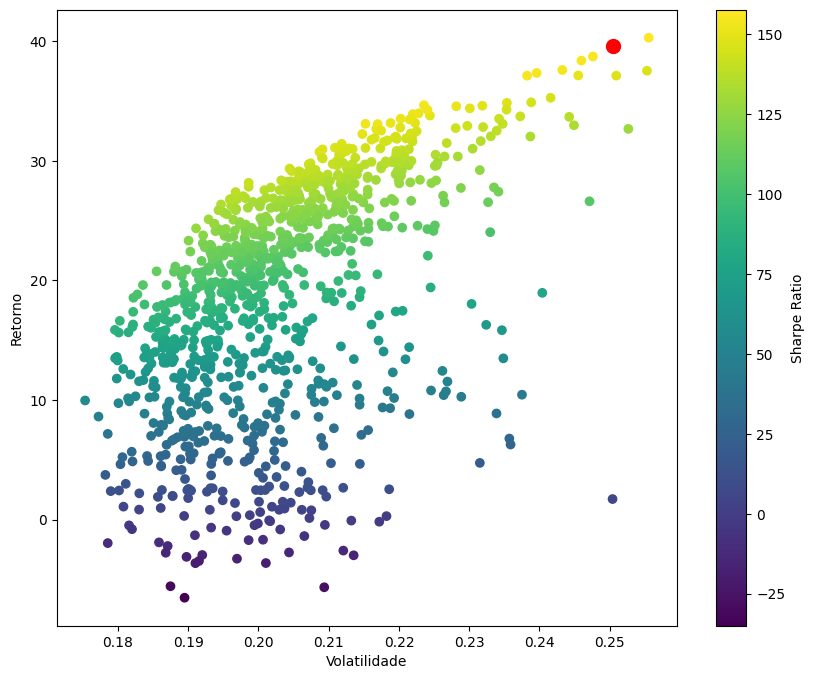

In [39]:
plt.figure(figsize=(10,8))
plt.scatter(ls_volatilidade, ls_retorno, c = ls_shape_ratio);
plt.colorbar(label = 'Sharpe Ratio')
plt.xlabel('Volatilidade')
plt.ylabel('Retorno')
plt.scatter(melhor_volatilidade, melhor_retono, c = 'red', s=100)

### Otimização de portifolio com algoritmos de otimização

In [41]:
df = (pd.read_csv('acoes.csv').rename(columns={'Unnamed: 0': 'Date'}))
dinheiro_total = 5000
sem_risco = taxa_selic_historico.mean() / 100
print(df.shape)
print(dinheiro_total)
print(sem_risco)
df.head()

(1037, 7)
5000
0.10886


,Date,VALE3.SA,PETR4.SA,BBDC4.SA,ABEV3.SA,EMBR3.SA,BOVA11.SA
0,2021-01-04,91.46,28.91,26.43,15.48,8.37,114.09
1,2021-01-05,93.00,30.04,26.25,15.81,8.57,114.69
2,2021-01-06,96.05,30.10,27.12,16.05,8.90,114.55
3,2021-01-07,102.32,31.00,27.84,16.05,8.88,118.37
4,2021-01-08,102.00,31.12,27.60,16.53,8.81,120.40


In [52]:
def fitness_function(solucao):
    dataset = df.copy()
    pesos = solucao / solucao.sum()
    
    for i in dataset.columns[1:]:
      dataset[i] = dataset[i] / dataset[i][0]

    for i, acao in enumerate(dataset.columns[1:]):
      dataset[acao] = dataset[acao] * pesos[i] * dinheiro_total

    dataset.drop(labels = ['Date'], axis = 1, inplace=True)
    dataset['Soma_Total'] = dataset.sum(axis = 1)
    dataset['Taxa_Retorno'] = 0.0

    for i in range(1, len(df)):
        dataset.loc[i, 'Taxa_Retorno'] = ((dataset.loc[i, 'Soma_Total'] / dataset.loc[i - 1, 'Soma_Total']) - 1) * 100

    sharpe_ratio = (dataset['Taxa_Retorno'].mean() - sem_risco) / dataset['Taxa_Retorno'].std() * np.sqrt(246)

    return sharpe_ratio
    

In [53]:
np.random.seed(10)
pesos = np.random.random(len(df.columns) - 1)
pesos = pesos / pesos.sum()
pesos

array([0.26617196, 0.00716121, 0.21866313, 0.25840174, 0.17202779,
       0.07757418])

In [54]:
fitness_function(pesos)

-0.3296728858177182

In [55]:
def visualiza_alocacao(solucao):
    dataset = df.copy()
    colunas = dataset.columns[1:]
    for i in range(len(solucao)):
        print(colunas[i], solucao[i] * 100) 

In [56]:
visualiza_alocacao(pesos)

VALE3.SA 26.617195545614496
PETR4.SA 0.7161207195395352
BBDC4.SA 21.866313475981215
ABEV3.SA 25.84017365648649
EMBR3.SA 17.202779081759033
BOVA11.SA 7.757417520619242


In [57]:
fitness = mlrose.CustomFitness(fitness_function)

In [82]:
problem_max = mlrose.ContinuousOpt(length=6, fitness_fn=fitness, maximize=True, min_val=0, max_val=1)
problem_min = mlrose.ContinuousOpt(length=6, fitness_fn=fitness, maximize=False, min_val=0, max_val=1)

### Hill Climb(Subida da encosta)

In [63]:
melhor_solucao, melhor_custo, curva = mlrose.hill_climb(problem_max, random_state= 42)
print(melhor_solucao) 
print(melhor_custo)
print(curva)

[0. 0. 0. 0. 1. 0.]
0.7445755950874651
None


In [64]:
melhor_solucao = melhor_solucao / melhor_solucao.sum()
melhor_solucao, melhor_solucao.sum()

(array([0., 0., 0., 0., 1., 0.]), 1.0)

In [65]:
visualiza_alocacao(melhor_solucao)

VALE3.SA 0.0
PETR4.SA 0.0
BBDC4.SA 0.0
ABEV3.SA 0.0
EMBR3.SA 100.0
BOVA11.SA 0.0


In [66]:
_, _, _, soma_valor = alocacao_ativos((pd.read_csv('acoes.csv').rename(columns={'Unnamed: 0': 'Date'})), 5000, melhores_pesos=melhor_solucao)
soma_valor

41648.745519713266

In [67]:
pior_solucao, pior_custo, pior_curva = mlrose.hill_climb(problem_min, random_state=42)
print(pior_solucao)
print(pior_custo)
print(pior_curva)

[0.57454012 0.         0.73199394 0.59865848 0.         0.        ]
-1.917984308039553
None


In [68]:
pior_solucao = pior_solucao / pior_solucao.sum()
pior_solucao, pior_solucao.sum()

(array([0.30156538, 0.        , 0.38420995, 0.31422466, 0.        ,
        0.        ]),
 1.0)

In [69]:
visualiza_alocacao(pior_solucao)

VALE3.SA 30.15653826688929
PETR4.SA 0.0
BBDC4.SA 38.42099549401746
ABEV3.SA 31.422466239093254
EMBR3.SA 0.0
BOVA11.SA 0.0


In [70]:
_, _, _, soma_valor = alocacao_ativos((pd.read_csv('acoes.csv').rename(columns={'Unnamed: 0': 'Date'})), 5000, melhores_pesos=pior_solucao)
soma_valor

2966.440154346841

### Simulated Annelating (Têmpera Simulada)

In [72]:
melhor_solucao, melhor_custo, melhor_curva = mlrose.simulated_annealing(problem_max, random_state=42)
print(melhor_solucao)
print(melhor_custo)
print(melhor_curva)

[0.  0.  0.  0.  0.4 0. ]
0.7445755950874651
None


In [74]:
melhor_solucao = melhor_solucao / melhor_solucao.sum()
melhor_solucao, melhor_solucao.sum()

(array([0., 0., 0., 0., 1., 0.]), 1.0)

In [75]:
visualiza_alocacao(melhor_solucao)

VALE3.SA 0.0
PETR4.SA 0.0
BBDC4.SA 0.0
ABEV3.SA 0.0
EMBR3.SA 100.0
BOVA11.SA 0.0


In [76]:
_, _, _, soma_valor = alocacao_ativos((pd.read_csv('acoes.csv').rename(columns={'Unnamed: 0': 'Date'})), 5000, melhores_pesos=melhor_solucao)
soma_valor

41648.745519713266

### Algoritmo Genetico

In [110]:
def fitness_quant(solucao):
    try:
        # ===============================
        # 1. Pesos
        # ===============================
        pesos = solucao / np.sum(solucao)

        # Penalização dura: pesos inválidos
        if np.any(pesos < 0) or not np.isfinite(pesos).all():
            return 1e-6

        # ===============================
        # 2. Limite máximo por ativo
        # ===============================
        max_peso = 0.4
        excesso = np.maximum(pesos - max_peso, 0).sum()

        # ===============================
        # 3. Portfólio
        # ===============================
        df_p = df_norm.copy()

        for i, ativo in enumerate(df_p.columns[1:]):
            df_p[ativo] *= pesos[i] * dinheiro_total

        df_p.drop(columns=['Date'], inplace=True)
        valor_port = df_p.sum(axis=1)

        retornos = valor_port.pct_change().dropna()

        if len(retornos) < 30:
            return 1e-6

        # ===============================
        # 4. Métricas
        # ===============================
        excesso_retorno = retornos - rf_diario

        vol = retornos.std()
        if vol < 1e-6:
            return 1e-6

        sharpe = excesso_retorno.mean() / vol * np.sqrt(246)

        # ===============================
        # 5. Penalizações
        # ===============================

        # Concentração (Herfindahl-Hirschman)
        hhi = np.sum(pesos ** 2)

        # Caudas (vol extrema)
        vol_extrema = retornos[retornos < retornos.quantile(0.05)].std()
        if not np.isfinite(vol_extrema):
            vol_extrema = 0

        # ===============================
        # 6. Função objetivo final
        # ===============================
        fitness = (
            sharpe
            - 0.5 * hhi
            - 0.3 * vol_extrema
            - 2.0 * excesso
        )

        return max(fitness, 1e-6)

    except Exception:
        return 1e-6

fitness_mlrose = mlrose.CustomFitness(fitness_quant)

In [112]:
problem_max_ag = mlrose.ContinuousOpt(
    length=len(df.columns) - 1,
    fitness_fn=fitness_mlrose,
    maximize=True,
    min_val=0.01,
    max_val=1
)

In [113]:
best_sol, best_fit, curve = mlrose.genetic_alg(
    problem_max_ag,
    pop_size=600,
    mutation_prob=0.05,
    max_attempts=300,
    max_iters=4000,
    curve=True,
    random_state=42
)

print(melhor_solucao)
print(melhor_custo)
# print(melhor_curva)
melhor_curva

[0.13361938 0.29214475 0.23196724 0.19528207 0.0734966  0.07348996]
1e-08


array([[1.00000e-08, 1.00200e+03],
       [1.00000e-08, 1.50300e+03],
       [1.00000e-08, 2.00400e+03],
       [1.00000e-08, 2.50500e+03],
       [1.00000e-08, 3.00600e+03],
       [1.00000e-08, 3.50700e+03],
       [1.00000e-08, 4.00800e+03],
       [1.00000e-08, 4.50900e+03],
       [1.00000e-08, 5.01000e+03],
       [1.00000e-08, 5.51100e+03],
       [1.00000e-08, 6.01200e+03],
       [1.00000e-08, 6.51300e+03],
       [1.00000e-08, 7.01400e+03],
       [1.00000e-08, 7.51500e+03],
       [1.00000e-08, 8.01600e+03],
       [1.00000e-08, 8.51700e+03],
       [1.00000e-08, 9.01800e+03],
       [1.00000e-08, 9.51900e+03],
       [1.00000e-08, 1.00200e+04],
       [1.00000e-08, 1.05210e+04],
       [1.00000e-08, 1.10220e+04],
       [1.00000e-08, 1.15230e+04],
       [1.00000e-08, 1.20240e+04],
       [1.00000e-08, 1.25250e+04],
       [1.00000e-08, 1.30260e+04],
       [1.00000e-08, 1.35270e+04],
       [1.00000e-08, 1.40280e+04],
       [1.00000e-08, 1.45290e+04],
       [1.00000e-08,

In [116]:
pesos_finais = best_sol / best_sol.sum()

pd.Series(
    pesos_finais,
    index=df.columns[1:]
).sort_values(ascending=False)

PETR4.SA     0.317255
BBDC4.SA     0.245035
ABEV3.SA     0.201009
VALE3.SA     0.127006
EMBR3.SA     0.054852
BOVA11.SA    0.054844
dtype: float64

In [117]:
melhor_solucao = melhor_solucao / melhor_solucao.sum()
melhor_solucao, melhor_solucao.sum()

(array([0.13361938, 0.29214475, 0.23196724, 0.19528207, 0.0734966 ,
        0.07348996]),
 1.0)

In [118]:
visualiza_alocacao(melhor_solucao)

VALE3.SA 13.36193831345647
PETR4.SA 29.214475025193074
BBDC4.SA 23.19672434450004
ABEV3.SA 19.528206589913026
EMBR3.SA 7.349659677074556
BOVA11.SA 7.3489960498628255


In [119]:
_, _, _, soma_valor = alocacao_ativos((pd.read_csv('acoes.csv').rename(columns={'Unnamed: 0': 'Date'})), 5000, melhores_pesos=melhor_solucao)
soma_valor

6930.063148171079